# 🤖 EfficientNetB0 Transfer Learning – staged fine-tuning

**Binary myopia classification from clinical fundus images**

This notebook converts the transfer learning script provided by the tutor (Abraham Otero) into a cleaner Jupyter Notebook format.  
The model uses **EfficientNetB0 pretrained on ImageNet** as a feature extractor and adds a custom binary classification head for myopia detection.

The training is performed in three stages:

1. **Stage 1 – frozen EfficientNetB0:** only the custom classification head is trained.
2. **Stage 2 – fine-tuning last 20 layers:** the previous model is loaded, the last 20 trainable EfficientNetB0 layers are unfrozen, and the model is recompiled with a lower learning rate.
3. **Stage 3 – fine-tuning last 40 layers:** the Stage 2 model is loaded, the last 40 trainable EfficientNetB0 layers are unfrozen, and the model is recompiled with an even lower learning rate.
4. **Stage 4 – fine-tuning last 60 layers:** the Stage 3 model is loaded, more EfficientNetB0 layers are unfrozen, and the model is trained with a very small learning rate.
5. **Stage 5 – fine-tuning last 80 layers:** the Stage 4 model is loaded, an even deeper portion of EfficientNetB0 is unfrozen, and the model is trained cautiously with a very small learning rate.

The loss function is **Binary Focal Crossentropy**, which gives more importance to difficult examples and to the positive class (Myopia).


-> Stage 1 es el modelo más “puro” de transfer learning: EfficientNetB0 está congelado y solo se entrena la cabeza nueva de clasificación/regresión. Es decir, se usa EfficientNetB0 como extractor fijo de características.

Stage 2-5 son pruebas de fine-tuning: se carga el modelo anterior, se descongela parte de EfficientNetB0 y se deja que algunas capas finales también aprendan con nuestras imágenes de retina.

## 🧠 0. What is transfer learning?

Transfer learning means using a neural network that has already learned useful visual patterns from a large dataset, in this case **ImageNet**, and adapting it to a new task.

Here, EfficientNetB0 already contains convolutional filters able to detect general image features such as edges, textures, shapes and local patterns. Instead of training all those filters from zero, we reuse them and train only a small custom head on top. Then, in later stages, we progressively unfreeze some of the final EfficientNetB0 layers so the model can adapt more specifically to fundus images.


## ⚙️ 1. Imports and reproducibility


In [1]:
from __future__ import annotations

#import argparse - not needed
import importlib
import sys
from pathlib import Path
from types import SimpleNamespace #extra addition
from typing import Any

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt #extra addition


#extra addition ----------------------------------------
SEED = 42 #
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Determinism could not be enabled:", e)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 🧾 2. Experiment configuration

These values can be adapteed if a different experiment is wanted (adapting the number of epochs, batch size...)

Important detail: this EfficientNetB0 implementation keeps images in the **0–255 pixel range**. This is different from some of the previous notebooks where images were converted to **0–1**.


In [2]:
# Experiment selected in config.yaml
EXPERIMENT = "full_preproc"

# Model/loss settings
HEAD = "mlp"
EFFICIENTNET_WEIGHTS = "imagenet"
FOCAL_ALPHA = 0.75
FOCAL_GAMMA = 2.0
THRESHOLD = 0.5

# Training settings - extra addition (#)
EPOCHS = 15 #
BATCH_SIZE_OVERRIDE = None # - Use None to read batch size from config.yaml
BASE_LEARNING_RATE = 1e-4 #
EARLY_STOPPING_PATIENCE = 5 #
REDUCE_LR_PATIENCE = 5 #
VERBOSE = 1 #

# Optional: force a project root manually if automatic detection fails.
# Example: PROJECT_ROOT_OVERRIDE = r"C:/Users/Paula/Desktop/TFG_Biomed"
PROJECT_ROOT_OVERRIDE = None # Extra addition

STAGES = [
    {
        "stage": 1,
        "name": "stage1_frozen",
        "unfreeze_last_n_layers": 0,
        "lr_multiplier": 1.0,
    },
    {
        "stage": 2,
        "name": "stage2_unfreeze20",
        "unfreeze_last_n_layers": 20,
        "lr_multiplier": 0.1,
    },
    {
        "stage": 3,
        "name": "stage3_unfreeze40",
        "unfreeze_last_n_layers": 40,
        "lr_multiplier": 0.01,
    },
    {
        "stage": 4,
        "name": "stage4_unfreeze60",
        "unfreeze_last_n_layers": 60,
        "lr_multiplier": 0.005,
    },
    {
        "stage": 5,
        "name": "stage5_unfreeze80",
        "unfreeze_last_n_layers": 80,
        "lr_multiplier": 0.002,
    },
]

#extra addition
args = SimpleNamespace(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_OVERRIDE,
    learning_rate=BASE_LEARNING_RATE,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    reduce_lr_patience=REDUCE_LR_PATIENCE,
    verbose=VERBOSE,
)


## 📁 3. Project paths

This cell searches for `config.yaml` and imports the helper functions from `src.paths`.

The notebook should be run from inside the project folder, or if failing, set `PROJECT_ROOT_OVERRIDE` in the previous cell.


In [3]:
def find_project_root(start: Path | None = None) -> Path: #extra addition: fixed for congif.yaml possible failure
    if PROJECT_ROOT_OVERRIDE is not None: 
        root = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if not (root / "config.yaml").exists():
            raise FileNotFoundError(f"config.yaml was not found in PROJECT_ROOT_OVERRIDE: {root}")
        return root

    root = (start or Path.cwd()).resolve()
    while not (root / "config.yaml").exists():
        if root == root.parent:
            raise FileNotFoundError(
                "config.yaml was not found. Run this notebook from inside the project "
                "or set PROJECT_ROOT_OVERRIDE in the configuration cell."
            )
        root = root.parent
    return root

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (  # noqa: E402
    get_experiment_paths,
    get_paths,
    load_config,
    validate_experiment_paths,
    validate_main_structure,
)

In [4]:
# parse_args function would be here, but I believe there is no longer need for it
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Train only the FullPreproc binary myopia classification model."
    )
    parser.add_argument("--epochs", type=int, default=10)
    parser.add_argument("--batch-size", type=int, default=None)
    parser.add_argument("--learning-rate", type=float, default=1e-4)
    parser.add_argument(
        "--early-stopping-patience",
        type=int,
        default=15,
        help="Epochs without val_auc improvement before stopping training.",
    )
    parser.add_argument(
        "--reduce-lr-patience",
        type=int,
        default=5,
        help="Epochs without val_auc improvement before reducing the learning rate.",
    )
    parser.add_argument(
        "--verbose",
        type=int,
        choices=[0, 1, 2],
        default=1,
        help="Keras console verbosity: 0=silent, 1=progress bar, 2=one line per epoch.",
    )
    return parser.parse_args()


In [5]:
# These are extra additions to read variables from config.yaml

cfg = load_config(PROJECT_ROOT / "config.yaml")
paths = get_paths(cfg)
validate_main_structure(paths)

exp_paths = get_experiment_paths(cfg, EXPERIMENT)
validate_experiment_paths(exp_paths)

seed = int(cfg["settings"].get("seed", SEED))
image_size = tuple(cfg["settings"]["image_size"])
batch_size = args.batch_size or int(cfg["settings"]["batch_size"])

TABLE_PATH = exp_paths["table"]
SPLIT_DIR = exp_paths["split_classification"]
MODELS_DIR = exp_paths["models_experiment"] #from yaml
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Experiment:", EXPERIMENT)
print("Table path:", TABLE_PATH)
print("Classification splits:", SPLIT_DIR)
print("Models output:", MODELS_DIR)
print("Image size:", image_size)
print("Batch size:", batch_size)
print("Seed:", seed)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Experiment: full_preproc
Table path: C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx
Classification splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc
Image size: (224, 224)
Batch size: 32
Seed: 42


## 🧹 4. Load and clean the matched table

The table is expected to contain at least these columns:

- `image_path`
- `filename`
- `patient_id`
- `class_label`

`class_label = 1` corresponds to **Myopia**, and `class_label = 0` corresponds to **Normal**.


In [6]:
def resolve_project_path(path: str | Path) -> Path:
    path = Path(path)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path

def resolve_project_path_str(path: str | Path) -> str:
    return str(resolve_project_path(path))

def load_and_clean_table(table_path: Path) -> pd.DataFrame:
    df = pd.read_excel(table_path)
    
    #extra addition
    required_cols = {"image_path", "filename", "patient_id", "class_label"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols: 
        raise ValueError(f"Missing required columns in matched table: {missing_cols}")

    df = df[df["image_path"].notna()].copy()
    df = df[df["class_label"].notna()].copy()

    df["image_path"] = df["image_path"].astype(str)
    df["filename"] = df["filename"].astype(str)
    df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
    df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce").astype("Int64")

    df = df.dropna(subset=["image_path", "filename", "patient_id", "class_label"]).copy()
    df["class_label"] = df["class_label"].astype("int32")

    missing_paths = df["image_path"].apply(lambda p: not resolve_project_path(p).exists()).sum()
    if missing_paths:
        raise FileNotFoundError(
            f"{missing_paths} image paths from the match table do not exist. "
            "Check whether image_path values are relative to PROJECT_ROOT."
        )

    return df

#extra addition: loading the table into a df to show it
df = load_and_clean_table(TABLE_PATH)

print("Total valid images:", len(df))
print("Patients:", df["patient_id"].nunique())
print("Classification label balance:")
print(df["class_label"].value_counts())
display(df.head())


Total valid images: 2126
Patients: 1061
Classification label balance:
class_label
0    1645
1     481
Name: count, dtype: int64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
1,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
2,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
3,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
4,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,NO,2023-04-12,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance


## ✂️ 5. Stratified IMAGE-level train/validation/test splits

This creates or reuses 80/10/10 classification splits while avoiding IMAGE leakage across sets.

This is important because the same patient can have several images. 


In [7]:
#NOTA: estas funciones hacían splits por pacietne, pero yo en el resto de modelos hago split por imagen
#De modo que cambio las funciones para adaptar el codigo a esta casuística

def assert_no_image_overlap(split_dir: Path) -> None:
    split_dfs = {
        name: pd.read_csv(split_dir / f"{name}.csv")
        for name in ["train", "val", "test"]
    }

    image_col = "image_path" if "image_path" in split_dfs["train"].columns else "filename"

    image_sets = {
        name: set(df_part[image_col].astype(str))
        for name, df_part in split_dfs.items()
    }

    pairs = [("train", "val"), ("train", "test"), ("val", "test")]

    for left, right in pairs:
        overlap = image_sets[left] & image_sets[right]
        if overlap:
            raise AssertionError(
                f"Image leakage detected between {left} and {right}: "
                f"{len(overlap)} repeated images. Example: {list(overlap)[:5]}"
            )

    print("OK: no exact image overlap across train/val/test.")


def create_and_save_splits(df: pd.DataFrame, split_dir: Path, seed: int) -> None:
    # Image-level split, same strategy as previous notebooks
    train_df, tmp_df = train_test_split(
        df,
        test_size=0.20,
        random_state=seed,
        shuffle=True,
        stratify=df["class_label"].astype(int),
    )

    val_df, test_df = train_test_split(
        tmp_df,
        test_size=0.50,
        random_state=seed,
        shuffle=True,
        stratify=tmp_df["class_label"].astype(int),
    )

    split_dir.mkdir(parents=True, exist_ok=True)
    train_df.to_csv(split_dir / "train.csv", index=False)
    val_df.to_csv(split_dir / "val.csv", index=False)
    test_df.to_csv(split_dir / "test.csv", index=False)

    print("Image-level splits created.")
    print("Split sizes:", len(train_df), len(val_df), len(test_df))
    print("Patient counts:", train_df["patient_id"].nunique(), val_df["patient_id"].nunique(), test_df["patient_id"].nunique())
    print("Classification balance:")
    print("train\n", train_df["class_label"].value_counts(normalize=True))
    print("val\n", val_df["class_label"].value_counts(normalize=True))
    print("test\n", test_df["class_label"].value_counts(normalize=True))

    assert_no_image_overlap(split_dir)


def validate_existing_splits(split_dir: Path) -> None:
    split_dfs = {
        name: pd.read_csv(split_dir / f"{name}.csv")
        for name in ["train", "val", "test"]
    }

    assert_no_image_overlap(split_dir)

    print("Existing image-level splits loaded.")
    print("Patient overlap across splits is allowed to keep compatibility with previous notebooks.")

    for name, split_df in split_dfs.items():
        print(
            f"{name}: {len(split_df)} images, "
            f"{split_df['patient_id'].nunique()} patients"
        )

    print("Classification balance:")
    for name, split_df in split_dfs.items():
        print(f"{name}\n", split_df["class_label"].value_counts(normalize=True))


def ensure_splits(df: pd.DataFrame, split_dir: Path, seed: int) -> None:
    split_files = [split_dir / f"{name}.csv" for name in ["train", "val", "test"]]

    if all(path.exists() for path in split_files): #selecting already-done splits
        print("Using existing image-level classification splits:", split_dir)
        validate_existing_splits(split_dir)
        return

    missing = [path.name for path in split_files if not path.exists()]
    print("Missing split files:", missing)
    print("Creating image-level classification splits:", split_dir)
    create_and_save_splits(df, split_dir, seed)

#addition: let's check this here and now, let's not move on until we make sure splits are OK
ensure_splits(df, SPLIT_DIR, seed)

Using existing image-level classification splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\FullPreproc
OK: no exact image overlap across train/val/test.
Existing image-level splits loaded.
Patient overlap across splits is allowed to keep compatibility with previous notebooks.
train: 1700 images, 1012 patients
val: 213 images, 199 patients
test: 213 images, 203 patients
Classification balance:
train
 class_label
0    0.773529
1    0.226471
Name: proportion, dtype: float64
val
 class_label
0    0.774648
1    0.225352
Name: proportion, dtype: float64
test
 class_label
0    0.774648
1    0.225352
Name: proportion, dtype: float64


## 🧮 6. TensorFlow datasets

This dataloader reads image paths from the split CSV files.

Unlike previous notebooks where images were converted to `[0, 1]`, here images are only cast to `float32`, keeping their values in the `[0, 255]` range before entering EfficientNetB0.


In [8]:
def make_datasets(
    split_dir: Path,
    image_size: tuple[int, int],
    batch_size: int,
    seed: int,
) -> tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:
    autotune = tf.data.AUTOTUNE
    shuffle_buffer_size = 2048

    augment = keras.Sequential( #extra: augmentations before decode_img
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.02),
            layers.RandomZoom(0.05),
        ],
        name="light_augmentation",
    )

    def decode_img(path, y):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.ensure_shape(img, [None, None, 3])
        img = tf.image.resize(img, image_size, method="bilinear")
        img = tf.cast(img, tf.float32)  # Keep pixel range 0-255 for EfficientNetB0
        return img, tf.cast(y, tf.float32)

    def make_classification_ds(csv_path: Path, training: bool = False) -> tf.data.Dataset:
        df_split = pd.read_csv(csv_path)
        paths = df_split["image_path"].map(resolve_project_path_str).astype(str).values
        labels = df_split["class_label"].astype("float32").values

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(decode_img, num_parallel_calls=autotune)

        if training:
            ds = ds.shuffle(
                shuffle_buffer_size,
                seed=seed,
                reshuffle_each_iteration=True,
            )
            ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=autotune)

        return ds.batch(batch_size).prefetch(autotune)

    return (
        make_classification_ds(split_dir / "train.csv", training=True),
        make_classification_ds(split_dir / "val.csv", training=False),
        make_classification_ds(split_dir / "test.csv", training=False),
    )

#extra: splitting here and now...
train_ds, val_ds, test_ds = make_datasets(
    split_dir=SPLIT_DIR,
    image_size=image_size,
    batch_size=batch_size,
    seed=seed,
)

#... and checking performance before moving on
for xb, yb in train_ds.take(1):
    print("Batch image shape:", xb.shape)
    print("Batch label shape:", yb.shape)
    print("Pixel range in batch:", float(tf.reduce_min(xb)), "to", float(tf.reduce_max(xb)))


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Pixel range in batch: 0.0 to 255.0


## 🧩 7. EfficientNetB0 model definition

EfficientNetB0 is used without its original classification layer (`include_top=False`).

The custom head is:

`GlobalAveragePooling2D → BatchNormalization → Dense(256, ReLU) → Dropout(0.4) → Dense(64, ReLU) → Dropout(0.2) → Dense(1, sigmoid)`

In [9]:
def configure_efficientnet_base_trainability( #switching this function to top of cell bc function below uses it (no need, but maked more sense "chronologically")
    base_model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")

    base_model.trainable = bool(unfreeze_last_n_layers)

    # Freeze everything first
    for layer in base_model.layers:
        layer.trainable = False

    if not unfreeze_last_n_layers:
        return

    # BatchNorm layers are kept frozen during fine-tuning for stability
    trainable_layers = [
        layer
        for layer in base_model.layers
        if not isinstance(layer, layers.BatchNormalization)
    ]

    for layer in trainable_layers[-unfreeze_last_n_layers:]:
        layer.trainable = True

def build_efficientnetb0_classification(
    input_shape: tuple[int, int, int],
    unfreeze_last_n_layers: int,
) -> keras.Model:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")
    
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights=EFFICIENTNET_WEIGHTS,
        input_shape=input_shape,
    )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)

    inputs = keras.Input(shape=input_shape)
    features = base_model(inputs, training=bool(unfreeze_last_n_layers))
    x = layers.GlobalAveragePooling2D()(features)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="efficientnetb0_classification")

def find_efficientnet_base(model: keras.Model) -> keras.Model | None:
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.startswith("efficientnet"):
            return layer
    return None


def configure_loaded_model_for_fine_tuning(
    model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        raise ValueError(
            "The loaded model does not contain an EfficientNet base. "
            "Check the previous stage model path."
        )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)


def count_trainable_base_layers(model: keras.Model) -> int | None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        return None
    return sum(
        1
        for layer in base_model.layers
        if layer.trainable and not isinstance(layer, layers.BatchNormalization)
    )


In [10]:
#These fucntions were supposed to be here, but I believe there's no need for them anymore:
def build_classification_model(
    input_shape: tuple[int, int, int],
    unfreeze_last_n_layers: int,
) -> keras.Model:
    return build_efficientnetb0_classification(
        input_shape=input_shape,
        unfreeze_last_n_layers=unfreeze_last_n_layers,
    )

## 🎯 8. Loss, optimizer, callbacks and metrics


In [11]:
def build_loss() -> keras.losses.Loss:
    return keras.losses.BinaryFocalCrossentropy(
        alpha=FOCAL_ALPHA,
        gamma=FOCAL_GAMMA,
        apply_class_balancing=True,
    )

def compile_model(model: keras.Model, learning_rate: float) -> None:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=build_loss(),
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"],
    )

#Extra: moving this function up here (makes sense chronologically)
class EpochConsoleLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch: int, logs: dict[str, Any] | None = None) -> None:
        logs = logs or {}
        lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        metric_names = ["loss", "auc", "accuracy", "val_loss", "val_auc", "val_accuracy"]
        metrics = []

        for name in metric_names:
            if name in logs:
                metrics.append(f"{name}={float(logs[name]):.6f}")

        metrics.append(f"lr={lr:.2e}")
        print(f"Epoch {epoch + 1}: " + " | ".join(metrics), flush=True)


def make_callbacks(args: SimpleNamespace) -> list[keras.callbacks.Callback]:
    return [
        EpochConsoleLogger(),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=args.early_stopping_patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.3,
            patience=args.reduce_lr_patience,
        ),
    ]


## 📊 9. Evaluation helpers

These functions calculate AUC, AP, accuracy, recall for myopia, confusion matrix and classification report.


In [12]:
def collect_classification_preds(
    model: keras.Model,
    ds: tf.data.Dataset,
) -> tuple[np.ndarray, np.ndarray]:
    y_true, y_score = [], []

    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())

    return np.array(y_true).astype(int), np.array(y_score).astype(float)

def evaluate_classification( model: keras.Model, test_ds: tf.data.Dataset, threshold: float = THRESHOLD) -> dict[str, Any]:
    y_true, y_score = collect_classification_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ap = average_precision_score(y_true, y_score)
    cm = confusion_matrix(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Myopia"],
        output_dict=True,
        zero_division=0, #helps for errors found on previous notebooks with 0 division, when plotting
    )

    print(classification_report(y_true, y_pred, target_names=["Normal", "Myopia"], zero_division=0))
    print("Confusion matrix:\n", cm)
    print(f"AUC: {roc_auc:.6f}")
    print(f"AP: {ap:.6f}")
    print(f"Accuracy@{threshold}: {(y_pred == y_true).mean():.6f}")

    return { #added a couple more vars to return (#)
        "auc": float(roc_auc),
        "average_precision": float(ap),
        f"accuracy@{threshold}": float((y_pred == y_true).mean()),
        "recall_myopia": float(report["Myopia"]["recall"]), #
        "precision_myopia": float(report["Myopia"]["precision"]), #
        "confusion_matrix": cm.tolist(),
        "classification_report": report,
        "fpr": fpr.tolist(), #
        "tpr": tpr.tolist(), #
        "precision_curve": precision.tolist(),
        "recall_curve": recall.tolist(),
        "y_true": y_true.tolist(), #
        "y_score": y_score.tolist(), #
        "y_pred": y_pred.tolist(), #
    }


## 💾 10. Output paths and stage training function


In [13]:
#extra addition: one route per stage (per model)
def stage_output_paths(models_dir: Path, stage: dict[str, Any]) -> tuple[Path, Path, Path]:
    stem = f"transfer_learning_classification_with_dropout_fullpreproc_{stage['name']}"
    return (models_dir / f"{stem}.keras")

def train_stage( #extra: moved here for chr. sense
    stage: dict[str, Any],
    args: SimpleNamespace,
    input_shape: tuple[int, int, int],
    train_ds: tf.data.Dataset,
    val_ds: tf.data.Dataset,
    test_ds: tf.data.Dataset,
    models_dir: Path,
    previous_model_path: Path | None,
    common_summary: dict[str, Any],
) -> tuple[dict[str, Any], dict[str, list[float]]]:
    stage_model_path, stage_summary_path, stage_preds_path = stage_output_paths(models_dir, stage)
    stage_lr = args.learning_rate * float(stage["lr_multiplier"])
    unfreeze_last_n_layers = int(stage["unfreeze_last_n_layers"])

    print("\n" + "=" * 72)
    print(f"Stage {stage['stage']}: {stage['name']}")
    print("Initial model:", previous_model_path)
    print("Unfreeze last N EfficientNetB0 layers:", unfreeze_last_n_layers)
    print("Learning rate:", stage_lr)
    print("Epochs requested:", args.epochs)
    print("=" * 72)

    if previous_model_path is None:
        model = build_efficientnetb0_classification(
            input_shape=input_shape,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )
    else:
        model = keras.models.load_model(previous_model_path, compile=False)
        configure_loaded_model_for_fine_tuning(
            model=model,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )

    trainable_base_layers = count_trainable_base_layers(model)
    print("EfficientNetB0 trainable base layers:", trainable_base_layers)

    compile_model(model, stage_lr)
    model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=args.epochs,
        callbacks=make_callbacks(args),
        verbose=args.verbose,
    )

    print("Keras test metrics:")
    keras_metrics = model.evaluate(test_ds, return_dict=True)
    print(keras_metrics)

    eval_metrics = evaluate_classification(model, test_ds, threshold=THRESHOLD)

    preds_df = pd.DataFrame({ #extra: for later (possibility for saving below as well)
        "y_true": eval_metrics["y_true"],
        "y_score": eval_metrics["y_score"],
        "y_pred": eval_metrics["y_pred"],
    })
    #preds_df.to_csv(stage_preds_path, index=False)
    #print("Stage predictions saved at:", stage_preds_path)

    model.save(stage_model_path)
    print("Stage model saved at:", stage_model_path)

    stage_summary = {
        **common_summary,
        "stage": stage["stage"],
        "stage_name": stage["name"],
        "model_path": str(stage_model_path),
        "predictions_path": str(stage_preds_path),
        "initial_model_path": str(previous_model_path) if previous_model_path else None,
        "learning_rate": stage_lr,
        "base_learning_rate": args.learning_rate,
        "lr_multiplier": float(stage["lr_multiplier"]),
        "unfreeze_last_n_layers": unfreeze_last_n_layers,
        "trainable_base_layers": trainable_base_layers,
        "epochs_requested": args.epochs,
        "epochs_run": len(history.history.get("loss", [])),
        "best_val_auc": float(np.max(history.history.get("val_auc", [np.nan]))),
        "best_val_accuracy": float(np.max(history.history.get("val_accuracy", [np.nan]))),
        "keras_test_metrics": {k: float(v) for k, v in keras_metrics.items()},
        "evaluation": {
            k: v for k, v in eval_metrics.items()
            if k not in {"y_true", "y_score", "y_pred"}
        },
    }

    return stage_summary, history.history #returnign history as well for plotting


## 🚀 11. Run the five training stages

This cell trains the full staged pipeline (what would've been the "main function").  
Each stage loads the previous model, recompiles it with its own learning rate, trains, evaluates and saves outputs.


In [14]:
input_shape = (*image_size, 3)

common_summary = {
    "table_path": str(TABLE_PATH),
    "split_dir": str(SPLIT_DIR),
    "experiment": EXPERIMENT,
    "image_size": list(image_size),
    "batch_size": batch_size,
    "seed": seed,
    "architecture": "efficientnetb0",
    "head": HEAD,
    "efficientnet_weights": EFFICIENTNET_WEIGHTS,
    "image_pixel_range": "0-255",
    "loss": "binary_focal_crossentropy",
    "focal_alpha": FOCAL_ALPHA,
    "focal_gamma": FOCAL_GAMMA,
    "threshold": THRESHOLD,
}

stage_summaries = []
stage_histories = {}
previous_model_path = None

for stage in STAGES:
    stage_summary, stage_history = train_stage(
        stage=stage,
        args=args,
        input_shape=input_shape,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        models_dir=MODELS_DIR,
        previous_model_path=previous_model_path,
        common_summary=common_summary,
    )

    stage_summaries.append(stage_summary)
    stage_histories[stage["name"]] = stage_history
    previous_model_path = Path(stage_summary["model_path"])

global_summary = {
    **common_summary,
    "base_learning_rate": args.learning_rate,
    "epochs_requested_per_stage": args.epochs,
    "stages": stage_summaries,
}




Stage 1: stage1_frozen
Initial model: None
Unfreeze last N EfficientNetB0 layers: 0
Learning rate: 0.0001
Epochs requested: 15
EfficientNetB0 trainable base layers: 0


Model: "efficientnetb0_classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 3,796,149 (14.48 MB)

 Non-trainable params: 602,991 (2.30 MB)

Epoch 1/15
Epoch 1: loss=0.074389 | auc=0.683173 | accuracy=0.629412 | val_loss=0.054611 | val_auc=0.762311 | val_accuracy=0.652582 | lr=2.00e-07
54/54 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.6303 - auc: 0.6878 - loss: 0.0709 - val_accuracy: 0.6526 - val_auc: 0.7623 - val_loss: 0.0546 - learning_rate: 2.0000e-07
Epoch 2/15
Epoch 2: loss=0.076378 | auc=0.678174 | accuracy=0.638824 | val_loss=0.055185 | val_auc=0.761048 | val_accuracy=0.652582 | lr=2.00e-07
54/54 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.6469 - auc: 0.6942 - loss: 0.0727 - val_accuracy: 0.6526 - val_auc: 0.7610 - val_loss: 0.0552 - learning_rate: 2.0000e-07
Epoch 3/15
Epoch 3: loss=0.076433 | auc=0.667608 | accuracy=0.628824 | val_loss=0.055724 | val_auc=0.756376 | val_accuracy=0.661972 | lr=2.00e-07
54/54 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.6308 - auc: 0.6564 - loss: 0.0792 - val_accuracy: 0.6620 - val_auc: 0.7564 - val_loss: 0.0557 - learning_rate: 2.0000e-07
Epoch 4/15
Epoch 4: loss=0.071737 

## 📋 12. Results table

This table is formatted similarly to the rest of the notebooks: AUC, AP, accuracy and recall for myopia.


In [15]:
results_rows = []

for summary in stage_summaries:
    ev = summary["evaluation"]
    results_rows.append({
        "stage": summary["stage"],
        "stage_name": summary["stage_name"],
        "unfreeze_last_n_layers": summary["unfreeze_last_n_layers"],
        "learning_rate": summary["learning_rate"],
        "epochs_run": summary["epochs_run"],
        "best_val_auc": summary["best_val_auc"],
        "test_auc": ev["auc"],
        "test_ap": ev["average_precision"],
        f"test_accuracy@{THRESHOLD}": ev[f"accuracy@{THRESHOLD}"],
        "test_recall_myopia": ev["recall_myopia"],
        "test_precision_myopia": ev["precision_myopia"],
        "model_path": summary["model_path"],
    })

results_df = pd.DataFrame(results_rows)
display(results_df)


,stage,stage_name,unfreeze_last_n_layers,learning_rate,epochs_run,best_val_auc,test_auc,test_ap,test_accuracy@0.5,test_recall_myopia,test_precision_myopia,model_path
0,1,stage1_frozen,0,1.000000e-04,9,0.758586,0.716667,0.400844,0.582160,0.812500,0.327731,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,2,stage2_unfreeze20,20,1.000000e-05,7,0.767235,0.718561,0.402844,0.629108,0.729167,0.346535,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,3,stage3_unfreeze40,40,1.000000e-06,7,0.765593,0.711490,0.409702,0.643192,0.687500,0.351064,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,4,stage4_unfreeze60,60,5.000000e-07,6,0.764710,0.713005,0.413350,0.647887,0.708333,0.357895,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
4,5,stage5_unfreeze80,80,2.000000e-07,6,0.762311,0.712374,0.414274,0.643192,0.708333,0.354167,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


## 📈 13. Training curves


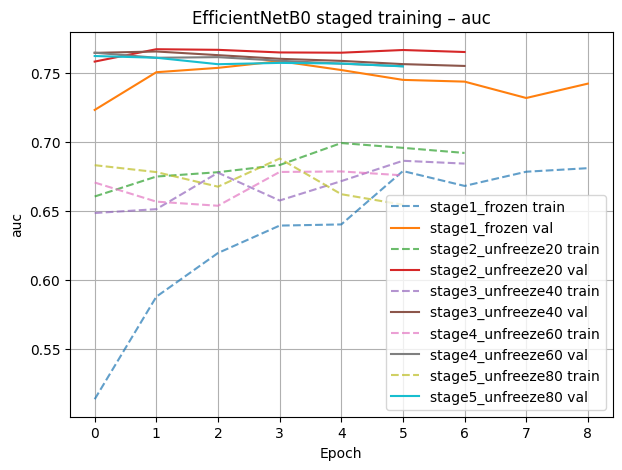

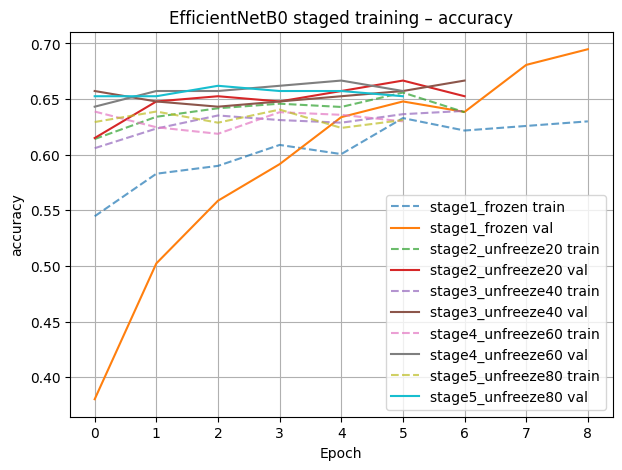

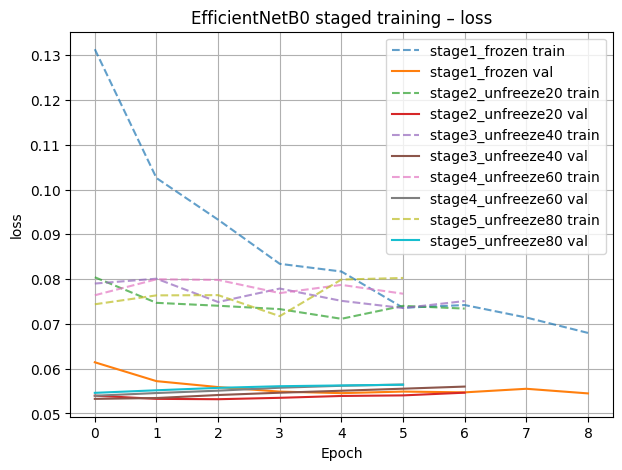

In [16]:
def plot_stage_histories(histories_dict: dict[str, dict[str, list[float]]], metric: str = "auc") -> None:
    plt.figure(figsize=(7, 5))

    for name, history in histories_dict.items():
        if metric in history:
            plt.plot(history[metric], linestyle="--", alpha=0.7, label=f"{name} train")
        if f"val_{metric}" in history:
            plt.plot(history[f"val_{metric}"], label=f"{name} val")

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"EfficientNetB0 staged training – {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_stage_histories(stage_histories, metric="auc")
plot_stage_histories(stage_histories, metric="accuracy")
plot_stage_histories(stage_histories, metric="loss")


## 📉 14. ROC and Precision-Recall curves


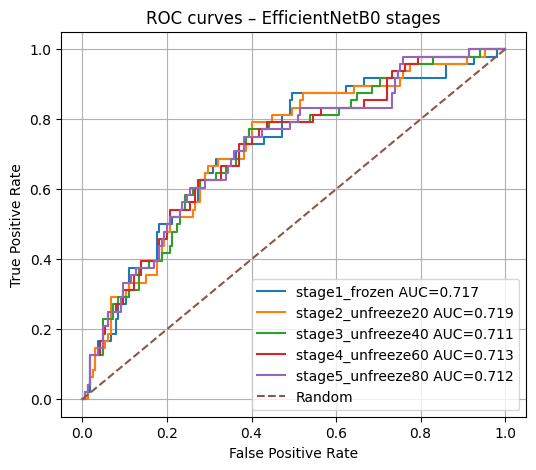

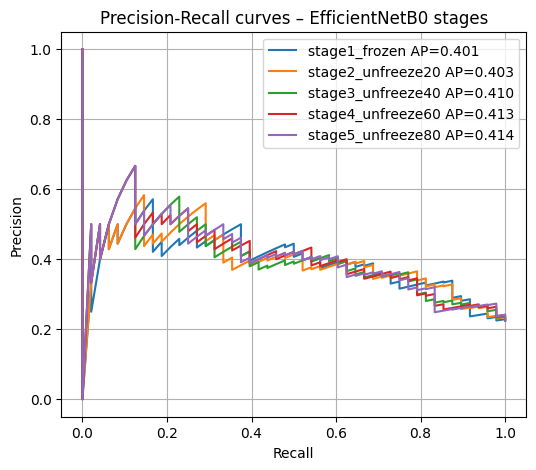

In [17]:
def plot_roc_pr_from_summaries(stage_summaries: list[dict[str, Any]]) -> None:
    plt.figure(figsize=(6, 5))
    for summary in stage_summaries:
        ev = summary["evaluation"]
        plt.plot(ev["fpr"], ev["tpr"], label=f"{summary['stage_name']} AUC={ev['auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curves – EfficientNetB0 stages")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 5))
    for summary in stage_summaries:
        ev = summary["evaluation"]
        plt.plot(ev["recall_curve"], ev["precision_curve"], label=f"{summary['stage_name']} AP={ev['average_precision']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curves – EfficientNetB0 stages")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_pr_from_summaries(stage_summaries)

## 🔢 15. Confusion matrices


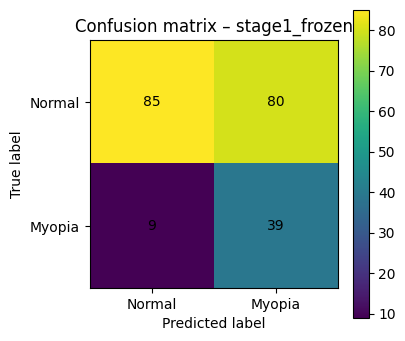

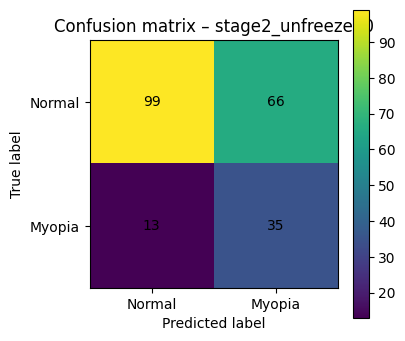

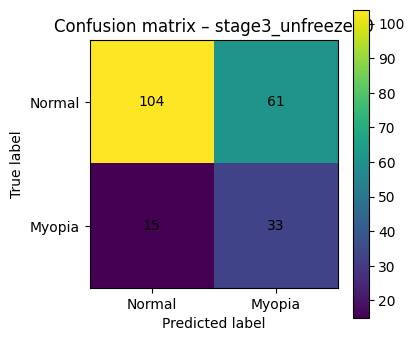

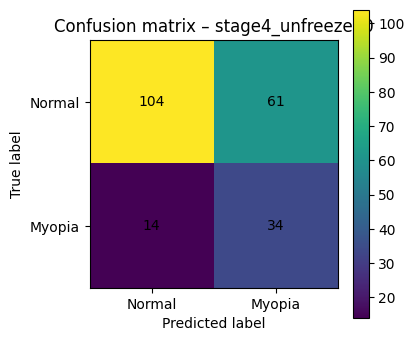

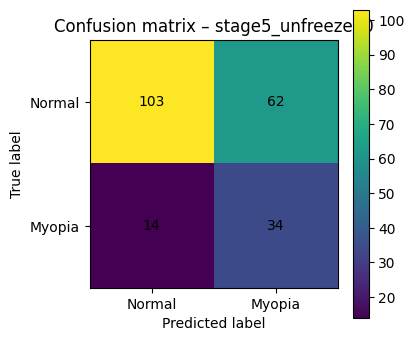

In [18]:
def plot_confusion_matrix(cm: list[list[int]], title: str) -> None:
    cm_arr = np.array(cm)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm_arr)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Normal", "Myopia"])
    plt.yticks([0, 1], ["Normal", "Myopia"])

    for i in range(cm_arr.shape[0]):
        for j in range(cm_arr.shape[1]):
            plt.text(j, i, str(cm_arr[i, j]), ha="center", va="center")

    plt.colorbar()
    plt.show()

for summary in stage_summaries:
    plot_confusion_matrix(
        summary["evaluation"]["confusion_matrix"],
        title=f"Confusion matrix – {summary['stage_name']}",
    )

## 📝 16. Results template (test)

Short text skeleton that can be adapted for the TFG results section.


In [19]:
best_auc_row = results_df.sort_values("test_auc", ascending=False).iloc[0]
best_recall_row = results_df.sort_values("test_recall_myopia", ascending=False).iloc[0]

print("Best stage by AUC:")
print(best_auc_row[["stage_name", "test_auc", f"test_accuracy@{THRESHOLD}", "test_recall_myopia"]])
print("\nBest stage by myopia recall:")
print(best_recall_row[["stage_name", "test_auc", f"test_accuracy@{THRESHOLD}", "test_recall_myopia"]])

Best stage by AUC:
stage_name            stage2_unfreeze20
test_auc                       0.718561
test_accuracy@0.5              0.629108
test_recall_myopia             0.729167
Name: 1, dtype: object

Best stage by myopia recall:
stage_name            stage1_frozen
test_auc                   0.716667
test_accuracy@0.5           0.58216
test_recall_myopia           0.8125
Name: 0, dtype: object


-> Clasificación: Stage 2 mejora AUC mínimamente, pero Stage 1 tiene mejor recall de miopía empleando muchos menos parámetros.